In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, length, to_date, to_timestamp, from_unixtime, lit, when

spark = SparkSession.builder.appName("reddit_eda").getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/19 23:05:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
SUBMISSIONS_CLEAN_PATH = "/project/macss/amritap1/redditproject/data/processed/submissions_clean_parquet"
COMMENTS_CLEAN_PATH = "/project/macss/amritap1/redditproject/data/processed/comments_clean_parquet"

submissions = spark.read.parquet(SUBMISSIONS_CLEAN_PATH)
comments = spark.read.parquet(COMMENTS_CLEAN_PATH)

print("Submissions:", submissions.count())
print("Comments:", comments.count())

submissions.printSchema()
comments.printSchema()

Submissions: 1371852


[Stage 5:========================================================>(57 + 1) / 58]

Comments: 54429003
root
 |-- id: string (nullable = true)
 |-- author: string (nullable = true)
 |-- created_utc: long (nullable = true)
 |-- title: string (nullable = true)
 |-- selftext: string (nullable = true)
 |-- score: long (nullable = true)
 |-- num_comments: long (nullable = true)
 |-- subreddit: string (nullable = true)
 |-- is_self: boolean (nullable = true)
 |-- link_flair_text: string (nullable = true)
 |-- url: string (nullable = true)
 |-- removed_by_category: string (nullable = true)
 |-- text: string (nullable = true)
 |-- created_ts: timestamp (nullable = true)
 |-- date: date (nullable = true)

root
 |-- id: string (nullable = true)
 |-- author: string (nullable = true)
 |-- text: string (nullable = true)
 |-- created_ts: timestamp (nullable = true)
 |-- date: date (nullable = true)
 |-- score: long (nullable = true)
 |-- subreddit: string (nullable = true)
 |-- parent_id: string (nullable = true)
 |-- link_id: string (nullable = true)



In [3]:
from pyspark.sql.functions import count as f_count

subs_daily = submissions.groupBy("date").agg(f_count("*").alias("submissions"))
coms_daily = comments.groupBy("date").agg(f_count("*").alias("comments"))

daily = subs_daily.join(coms_daily, on="date", how="outer").orderBy("date")
daily = daily.fillna(0).withColumn("comments_per_submission", col("comments") / col("submissions"))

daily.show(10)
daily.orderBy(col("submissions").desc()).show(10)
daily.orderBy(col("comments").desc()).show(10)

+----------+-----------+--------+-----------------------+
|      date|submissions|comments|comments_per_submission|
+----------+-----------+--------+-----------------------+
|2019-12-31|         24|    1353|                 56.375|
|2020-01-01|        104|    4760|      45.76923076923077|
|2020-01-02|        259|   14678|      56.67181467181467|
|2020-01-03|        236|   12581|     53.309322033898304|
|2020-01-04|        107|    4857|      45.39252336448598|
|2020-01-05|        108|    6683|     61.879629629629626|
|2020-01-06|        167|   11767|      70.46107784431138|
|2020-01-07|        286|   18022|      63.01398601398601|
|2020-01-08|        274|   16989|     62.003649635036496|
|2020-01-09|        268|   15224|      56.80597014925373|
+----------+-----------+--------+-----------------------+
only showing top 10 rows



+----------+-----------+--------+-----------------------+
|      date|submissions|comments|comments_per_submission|
+----------+-----------+--------+-----------------------+
|2021-01-28|     129448|  856584|      6.617205364316173|
|2021-01-29|      70389|  682236|      9.692366705024932|
|2021-01-27|      60238|  794127|     13.183156811315117|
|2021-02-01|      53562|  377375|       7.04557335424368|
|2021-02-02|      48795|  418126|       8.56903371247054|
|2021-01-30|      35078|  362176|      10.32487599064941|
|2021-01-31|      31263|  382862|      12.24648946038448|
|2021-02-03|      24284|  218869|      9.012889145116127|
|2021-02-04|      23291|  316904|     13.606285689751406|
|2021-01-26|      17383|  520425|     29.938733245124546|
+----------+-----------+--------+-----------------------+
only showing top 10 rows

+----------+-----------+--------+-----------------------+
|      date|submissions|comments|comments_per_submission|
+----------+-----------+--------+-------------

In [4]:
from pyspark.sql.functions import length, lower, regexp_extract, when, sum as f_sum, expr

subs_text = submissions.select("text")
coms_text = comments.select("text")

def text_stats(df, label):
    stats = (
        df.withColumn("len", length(col("text")))
          .withColumn("has_link", col("text").rlike(r"http[s]?://"))
          .withColumn("has_allcaps", col("text").rlike(r"\b[A-Z]{5,}\b"))
          .withColumn("has_punct", col("text").rlike(r"(!{3,}|\?{3,})"))
          .agg(
              expr("percentile(len, array(0.25, 0.5, 0.75, 0.9, 0.99))").alias("len_quantiles"),
              expr("avg(len)").alias("avg_len"),
              f_sum(when(col("has_link"), 1).otherwise(0)).alias("link_count"),
              f_sum(when(col("has_allcaps"), 1).otherwise(0)).alias("allcaps_count"),
              f_sum(when(col("has_punct"), 1).otherwise(0)).alias("punct_count"),
              f_count("*").alias("total")
          )
    )
    print(label)
    stats.show(truncate=False)

text_stats(subs_text, "Submissions text stats")
text_stats(coms_text, "Comments text stats")

Submissions text stats


+---------------------------------+-----------------+----------+-------------+-----------+-------+
|len_quantiles                    |avg_len          |link_count|allcaps_count|punct_count|total  |
+---------------------------------+-----------------+----------+-------------+-----------+-------+
|[27.0, 44.0, 76.0, 150.0, 2051.0]|133.9807872860921|38581     |164586       |61161      |1371852|
+---------------------------------+-----------------+----------+-------------+-----------+-------+

Comments text stats


[Stage 33:=======================================================>(57 + 1) / 58]

+--------------------------------+-----------------+----------+-------------+-----------+--------+
|len_quantiles                   |avg_len          |link_count|allcaps_count|punct_count|total   |
+--------------------------------+-----------------+----------+-------------+-----------+--------+
|[25.0, 49.0, 96.0, 178.0, 704.0]|86.63338069962442|1188669   |2175991      |687858     |54429003|
+--------------------------------+-----------------+----------+-------------+-----------+--------+



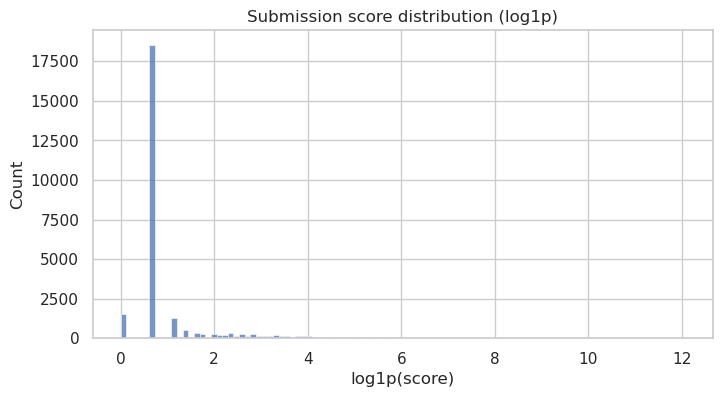

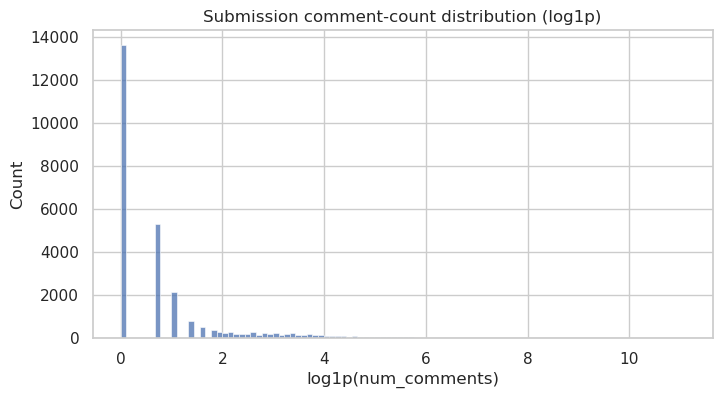

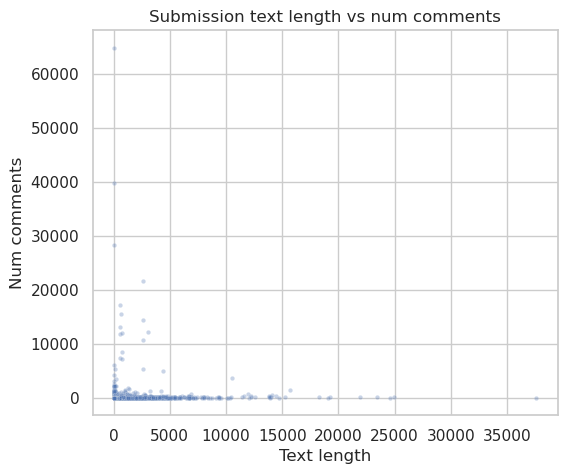

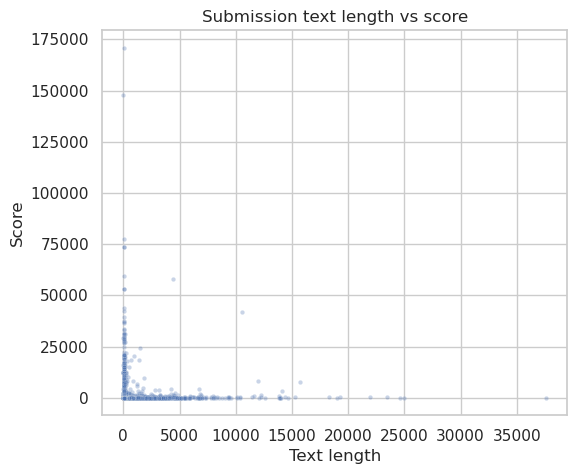

/software/python-anaconda-2023.09-el8-x86_64/envs/rapids-24.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/software/python-anaconda-2023.09-el8-x86_64/envs/rapids-24.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


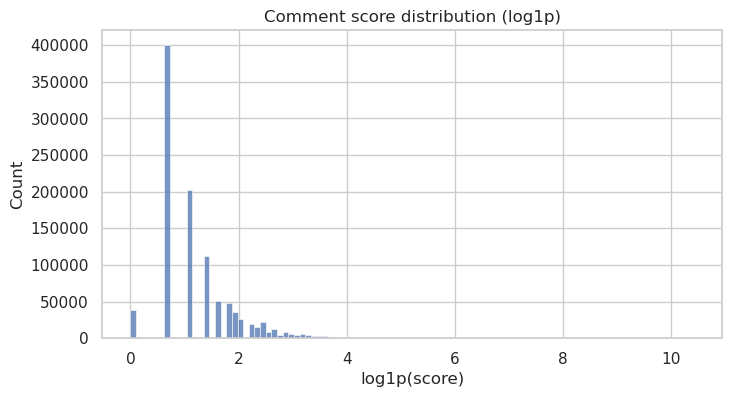

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Engagement distributions for submissions
subs_eng = submissions.select("score", "num_comments", "text")
subs_eng = subs_eng.withColumn("text_len", length(col("text")))

# Aggregate small samples for plotting
subs_eng_pd = subs_eng.sample(fraction=0.02, seed=42).toPandas()  # downsample for plotting
subs_eng_pd["score_log1p"] = np.log1p(subs_eng_pd["score"])
subs_eng_pd["num_comments_log1p"] = np.log1p(subs_eng_pd["num_comments"])

plt.figure(figsize=(8, 4))
sns.histplot(subs_eng_pd["score_log1p"], bins=100)
plt.title("Submission score distribution (log1p)")
plt.xlabel("log1p(score)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(subs_eng_pd["num_comments_log1p"], bins=100)
plt.title("Submission comment-count distribution (log1p)")
plt.xlabel("log1p(num_comments)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=subs_eng_pd,
    x="text_len",
    y="num_comments",
    alpha=0.3,
    s=10
)
plt.title("Submission text length vs num comments")
plt.xlabel("Text length")
plt.ylabel("Num comments")
plt.show()

plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=subs_eng_pd,
    x="text_len",
    y="score",
    alpha=0.3,
    s=10
)
plt.title("Submission text length vs score")
plt.xlabel("Text length")
plt.ylabel("Score")
plt.show()

# Comment score distribution
coms_score_pd = comments.select("score").sample(fraction=0.02, seed=42).toPandas()
coms_score_pd["score_log1p"] = np.log1p(coms_score_pd["score"])

plt.figure(figsize=(8, 4))
sns.histplot(coms_score_pd["score_log1p"], bins=100)
plt.title("Comment score distribution (log1p)")
plt.xlabel("log1p(score)")
plt.ylabel("Count")
plt.show()

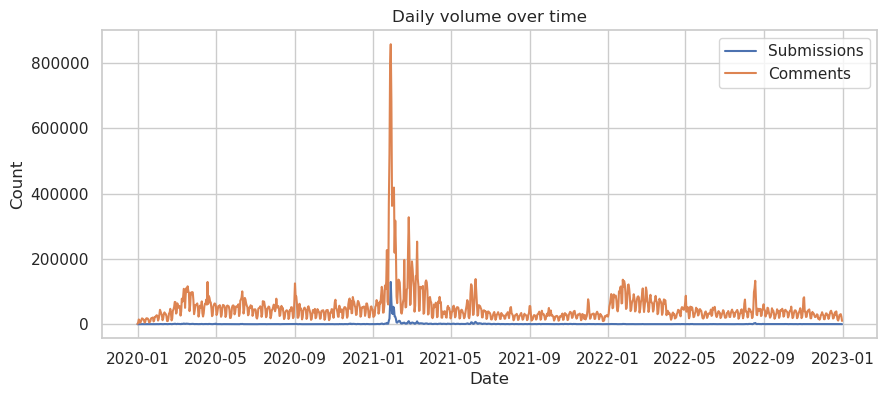

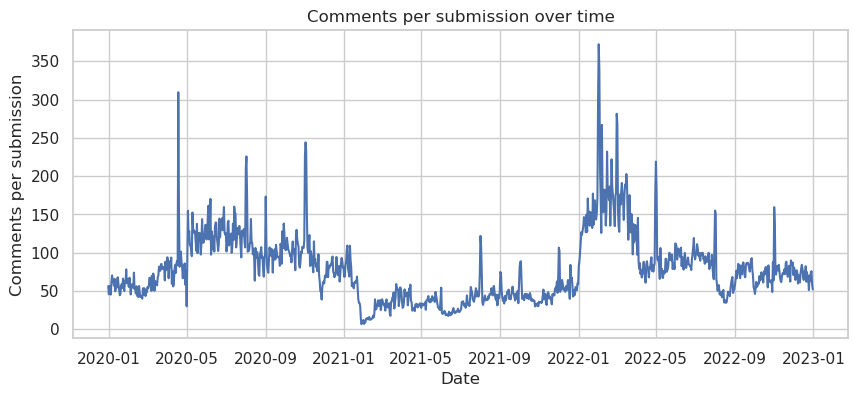

In [6]:
import pandas as pd

# Daily aggregation (already computed earlier as `daily`)
daily_pd = daily.toPandas().sort_values("date")

plt.figure(figsize=(10, 4))
sns.lineplot(data=daily_pd, x="date", y="submissions", label="Submissions")
sns.lineplot(data=daily_pd, x="date", y="comments", label="Comments")
plt.title("Daily volume over time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
sns.lineplot(data=daily_pd, x="date", y="comments_per_submission")
plt.title("Comments per submission over time")
plt.xlabel("Date")
plt.ylabel("Comments per submission")
plt.show()

In [7]:
from pyspark.sql import functions as F

# COMMENTS: numeric stats
comments_count = comments.count()

comments_stats = comments.select(
    F.count("*").alias("total_count"),
    F.countDistinct("author").alias("unique_authors"),
    F.min("created_ts").alias("min_created_ts"),
    F.max("created_ts").alias("max_created_ts"),
    F.avg("score").alias("avg_score"),
    F.stddev("score").alias("std_score"),
    F.min("score").alias("min_score"),
    F.max("score").alias("max_score"),
    F.avg(F.length("text")).alias("avg_text_length"),
    F.min(F.length("text")).alias("min_text_length"),
    F.max(F.length("text")).alias("max_text_length")
).collect()[0]

print("COMMENTS: NUMERIC STATS")
print(f"Total Records:    {comments_stats['total_count']:,}")
print(f"Unique Authors:   {comments_stats['unique_authors']:,}")
print(f"Time Range:       {comments_stats['min_created_ts']} to {comments_stats['max_created_ts']}")
print(f"Score Avg/Std:    {comments_stats['avg_score']:.2f} / {comments_stats['std_score']:.2f}")
print(f"Score Min/Max:    {comments_stats['min_score']} / {comments_stats['max_score']}")
print(f"Text Len Avg/Min/Max: {comments_stats['avg_text_length']:.2f} / {comments_stats['min_text_length']} / {comments_stats['max_text_length']}")

# COMMENTS: score percentiles
comments_score_pct = comments.select(
    F.expr("percentile_approx(score, 0.25)").alias("p25"),
    F.expr("percentile_approx(score, 0.50)").alias("p50"),
    F.expr("percentile_approx(score, 0.75)").alias("p75"),
    F.expr("percentile_approx(score, 0.90)").alias("p90"),
    F.expr("percentile_approx(score, 0.95)").alias("p95"),
    F.expr("percentile_approx(score, 0.99)").alias("p99")
).collect()[0]

print("\nCOMMENTS: SCORE PERCENTILES")
print(comments_score_pct)

COMMENTS: NUMERIC STATS
Total Records:    54,429,003
Unique Authors:   1,704,616
Time Range:       2019-12-31 18:00:04 to 2022-12-31 17:59:53
Score Avg/Std:    7.18 / 96.42
Score Min/Max:    -3305 / 71870
Text Len Avg/Min/Max: 86.63 / 1 / 10147


[Stage 61:>                                                         (0 + 1) / 1]


COMMENTS: SCORE PERCENTILES
Row(p25=1, p50=2, p75=4, p90=9, p95=17, p99=71)


In [8]:
from pyspark.sql import functions as F

# COMMENTS: nulls
print("\nCOMMENTS: NULL COUNTS")
null_counts = comments.select([
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in comments.columns
]).collect()[0]

for c in comments.columns:
    n = null_counts[c]
    pct = (n / comments_count) * 100 if comments_count else 0
    print(f"{c:20s} {n:12,d} ({pct:6.2f}%)")

# COMMENTS: possible bot accounts
bot_comments = comments.filter(
    F.lower(F.col("author")).rlike("automoderator|moderator|\\bbot\\b|automod")
)
bot_comments_count = bot_comments.count()
print(f"\nCOMMENTS: BOT-LIKE AUTHORS = {bot_comments_count:,} ({bot_comments_count/comments_count*100:.2f}%)")
bot_comments.groupBy("author").count().orderBy(F.desc("count")).show(20, truncate=False)

# SUBMISSIONS: numeric stats
submissions_count = submissions.count()

submissions_stats = submissions.select(
    F.count("*").alias("total_count"),
    F.countDistinct("author").alias("unique_authors"),
    F.min("created_ts").alias("min_created_ts"),
    F.max("created_ts").alias("max_created_ts"),
    F.avg("score").alias("avg_score"),
    F.stddev("score").alias("std_score"),
    F.min("score").alias("min_score"),
    F.max("score").alias("max_score"),
    F.avg("num_comments").alias("avg_num_comments"),
    F.stddev("num_comments").alias("std_num_comments"),
    F.min("num_comments").alias("min_num_comments"),
    F.max("num_comments").alias("max_num_comments"),
    F.avg(F.length("text")).alias("avg_text_length"),
    F.min(F.length("text")).alias("min_text_length"),
    F.max(F.length("text")).alias("max_text_length")
).collect()[0]

print("\nSUBMISSIONS: NUMERIC STATS")
print(f"Total Records:    {submissions_stats['total_count']:,}")
print(f"Unique Authors:   {submissions_stats['unique_authors']:,}")
print(f"Time Range:       {submissions_stats['min_created_ts']} to {submissions_stats['max_created_ts']}")
print(f"Score Avg/Std:    {submissions_stats['avg_score']:.2f} / {submissions_stats['std_score']:.2f}")
print(f"Score Min/Max:    {submissions_stats['min_score']} / {submissions_stats['max_score']}")
print(f"NumComments Avg/Std: {submissions_stats['avg_num_comments']:.2f} / {submissions_stats['std_num_comments']:.2f}")
print(f"NumComments Min/Max: {submissions_stats['min_num_comments']} / {submissions_stats['max_num_comments']}")
print(f"Text Len Avg/Min/Max: {submissions_stats['avg_text_length']:.2f} / {submissions_stats['min_text_length']} / {submissions_stats['max_text_length']}")

# SUBMISSIONS: score percentiles
submissions_score_pct = submissions.select(
    F.expr("percentile_approx(score, 0.25)").alias("p25"),
    F.expr("percentile_approx(score, 0.50)").alias("p50"),
    F.expr("percentile_approx(score, 0.75)").alias("p75"),
    F.expr("percentile_approx(score, 0.90)").alias("p90"),
    F.expr("percentile_approx(score, 0.95)").alias("p95"),
    F.expr("percentile_approx(score, 0.99)").alias("p99")
).collect()[0]

print("\nSUBMISSIONS: SCORE PERCENTILES")
print(submissions_score_pct)

# SUBMISSIONS: num_comments percentiles
submissions_comments_pct = submissions.select(
    F.expr("percentile_approx(num_comments, 0.25)").alias("p25"),
    F.expr("percentile_approx(num_comments, 0.50)").alias("p50"),
    F.expr("percentile_approx(num_comments, 0.75)").alias("p75"),
    F.expr("percentile_approx(num_comments, 0.90)").alias("p90"),
    F.expr("percentile_approx(num_comments, 0.95)").alias("p95"),
    F.expr("percentile_approx(num_comments, 0.99)").alias("p99")
).collect()[0]

print("\nSUBMISSIONS: NUM_COMMENTS PERCENTILES")
print(submissions_comments_pct)


COMMENTS: NULL COUNTS


id                              0 (  0.00%)
author                          0 (  0.00%)
text                            0 (  0.00%)
created_ts                      0 (  0.00%)
date                            0 (  0.00%)
score                           0 (  0.00%)
subreddit                       0 (  0.00%)
parent_id                       0 (  0.00%)
link_id                         0 (  0.00%)



COMMENTS: BOT-LIKE AUTHORS = 11,287 (0.02%)


+--------------------+-----+
|author              |count|
+--------------------+-----+
|red-bot             |1507 |
|ModeratorInTraining |1105 |
|Upside_Down-Bot     |1094 |
|converter-bot       |1054 |
|anti-gif-bot        |708  |
|TheModeratorWrangler|605  |
|Paid-Not-Payed-Bot  |551  |
|PORTMANTEAU-BOT     |531  |
|_automod_bot_       |478  |
|LimbRetrieval-Bot   |358  |
|GANDHI-BOT          |278  |
|etch-bot            |242  |
|Not_a-bot-i_swear   |229  |
|LuckyNumber-Bot     |178  |
|ModeratoriProfugus  |155  |
|pee-reminder-bot    |154  |
|happy-cake-day-bot- |138  |
|reply-guy-bot       |111  |
|Bot-Magnet          |106  |
|AutoModAccountOpUrk |106  |
+--------------------+-----+
only showing top 20 rows




SUBMISSIONS: NUMERIC STATS
Total Records:    1,371,852
Unique Authors:   668,269
Time Range:       2019-12-31 18:04:32 to 2022-12-31 17:51:48
Score Avg/Std:    142.72 / 2285.25
Score Min/Max:    0 / 417276
NumComments Avg/Std: 26.67 / 671.21
NumComments Min/Max: 0 / 100002
Text Len Avg/Min/Max: 133.98 / 2 / 42542



SUBMISSIONS: SCORE PERCENTILES
Row(p25=1, p50=1, p75=2, p90=26, p95=107, p99=1830)


[Stage 83:===================>                                      (3 + 6) / 9]


SUBMISSIONS: NUM_COMMENTS PERCENTILES
Row(p25=0, p50=1, p75=2, p90=17, p95=43, p99=249)


26/04/20 00:02:51 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/20 00:02:51 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/20 00:02:51 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/20 00:02:51 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/20 00:02:51 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/20 00:02:51 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/20 00:02:51 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/20 00:02:51 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/20 00:02:51 WARN RowBasedKeyValueBatch: Calling spill() on

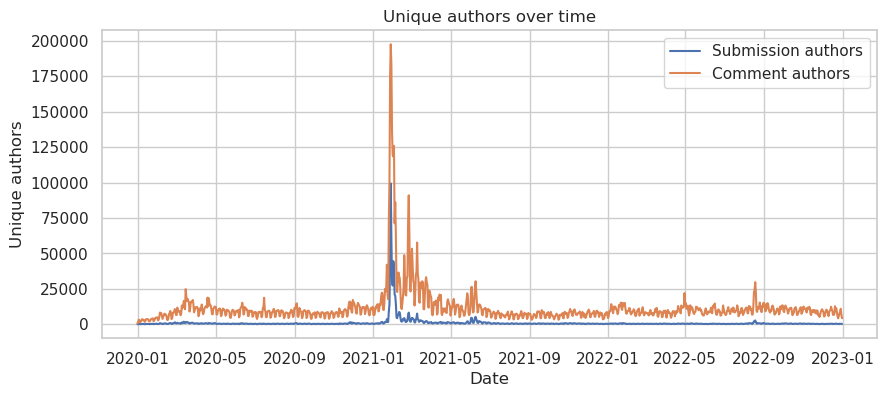

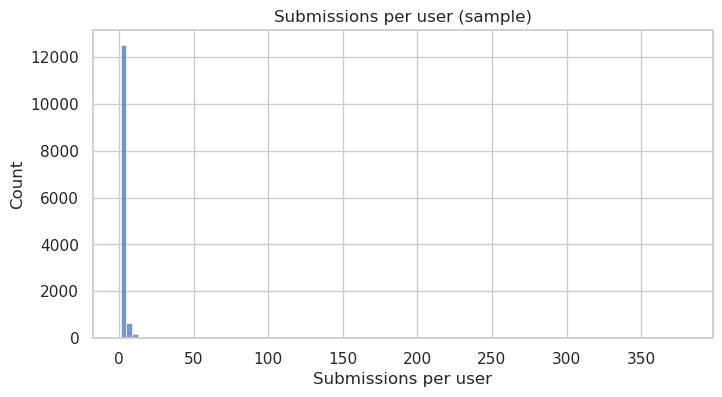

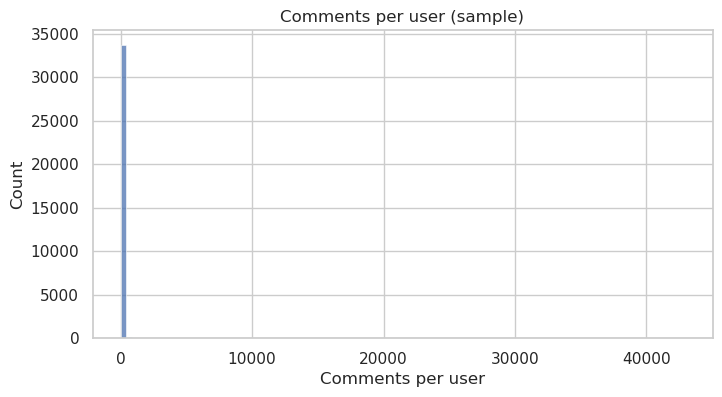

In [21]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Unique authors over time
subs_auth_daily = submissions.groupBy("date").agg(F.countDistinct("author").alias("unique_sub_authors"))
coms_auth_daily = comments.groupBy("date").agg(F.countDistinct("author").alias("unique_com_authors"))

auth_daily = subs_auth_daily.join(coms_auth_daily, on="date", how="outer").orderBy("date").fillna(0)
auth_daily_pd = auth_daily.toPandas()

plt.figure(figsize=(10, 4))
sns.lineplot(data=auth_daily_pd, x="date", y="unique_sub_authors", label="Submission authors")
sns.lineplot(data=auth_daily_pd, x="date", y="unique_com_authors", label="Comment authors")
plt.title("Unique authors over time")
plt.xlabel("Date")
plt.ylabel("Unique authors")
plt.legend()
plt.show()

# Posts/comments per user distribution
subs_per_user = submissions.groupBy("author").count().withColumnRenamed("count", "subs_count")
coms_per_user = comments.groupBy("author").count().withColumnRenamed("count", "coms_count")

subs_per_user_pd = subs_per_user.sample(fraction=0.02, seed=42).toPandas()
coms_per_user_pd = coms_per_user.sample(fraction=0.02, seed=42).toPandas()

plt.figure(figsize=(8, 4))
sns.histplot(subs_per_user_pd["subs_count"], bins=100)
plt.title("Submissions per user (sample)")
plt.xlabel("Submissions per user")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(coms_per_user_pd["coms_count"], bins=100)
plt.title("Comments per user (sample)")
plt.xlabel("Comments per user")
plt.ylabel("Count")
plt.show()

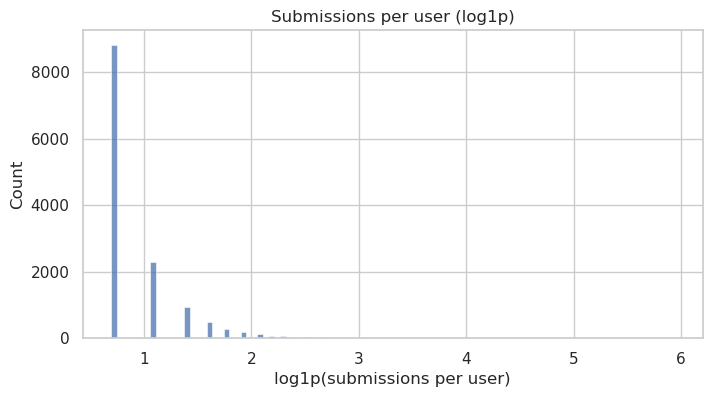

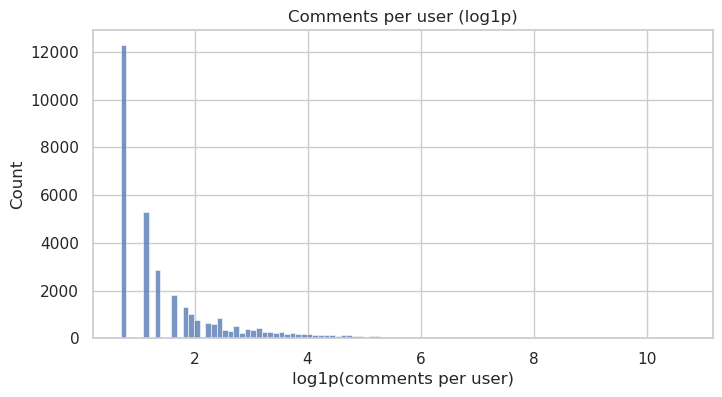

In [22]:
import numpy as np

subs_per_user_pd["subs_log1p"] = np.log1p(subs_per_user_pd["subs_count"])
coms_per_user_pd["coms_log1p"] = np.log1p(coms_per_user_pd["coms_count"])

plt.figure(figsize=(8, 4))
sns.histplot(subs_per_user_pd["subs_log1p"], bins=100)
plt.title("Submissions per user (log1p)")
plt.xlabel("log1p(submissions per user)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(coms_per_user_pd["coms_log1p"], bins=100)
plt.title("Comments per user (log1p)")
plt.xlabel("log1p(comments per user)")
plt.ylabel("Count")
plt.show()

## Sentiment Analysis

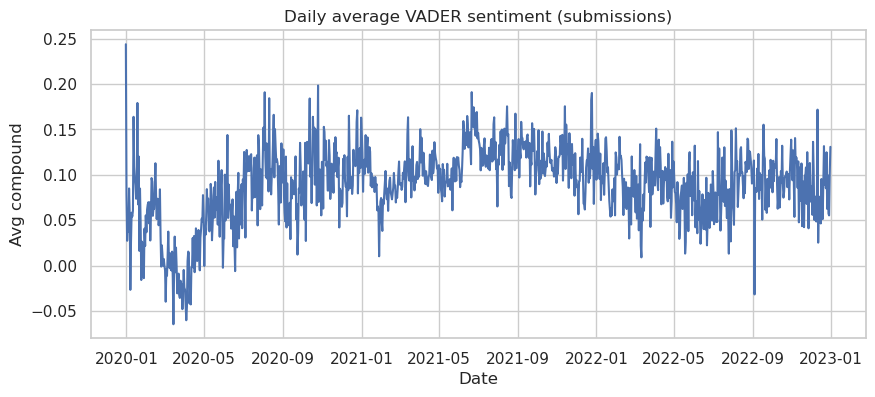

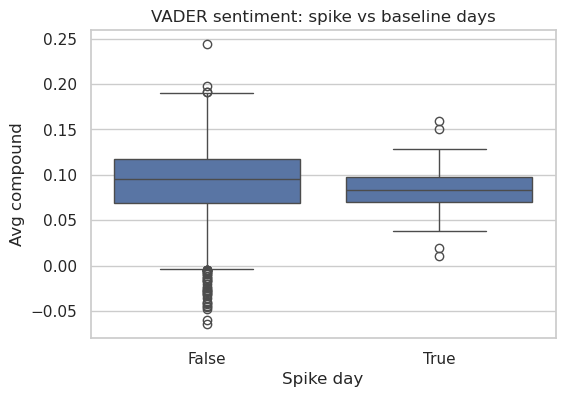

In [9]:
# If vaderSentiment is not installed, run this once:
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
except ImportError:
    import sys
    !{sys.executable} -m pip -q install vaderSentiment
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

sns.set(style="whitegrid")

# Choose text source (submissions is lighter than comments)
text_source = submissions.select("date", "text")

analyzer = SentimentIntensityAnalyzer()

@F.udf(DoubleType())
def vader_compound(text):
    if text is None:
        return None
    return analyzer.polarity_scores(text)["compound"]

sent_df = text_source.withColumn("compound", vader_compound(F.col("text"))).dropna(subset=["compound"])

# Daily sentiment mean
sent_daily = sent_df.groupBy("date").agg(
    F.avg("compound").alias("avg_compound"),
    F.count("*").alias("n")
).orderBy("date")

sent_daily_pd = sent_daily.toPandas()

plt.figure(figsize=(10, 4))
sns.lineplot(data=sent_daily_pd, x="date", y="avg_compound")
plt.title("Daily average VADER sentiment (submissions)")
plt.xlabel("Date")
plt.ylabel("Avg compound")
plt.show()

# Spike vs baseline (define spikes using daily comments from earlier `daily` table)
daily_pd = daily.toPandas().sort_values("date")
spike_threshold = daily_pd["comments"].quantile(0.95)

spike_days = set(daily_pd[daily_pd["comments"] >= spike_threshold]["date"])
sent_daily_pd["is_spike"] = sent_daily_pd["date"].isin(spike_days)

plt.figure(figsize=(6, 4))
sns.boxplot(data=sent_daily_pd, x="is_spike", y="avg_compound")
plt.title("VADER sentiment: spike vs baseline days")
plt.xlabel("Spike day")
plt.ylabel("Avg compound")
plt.show()

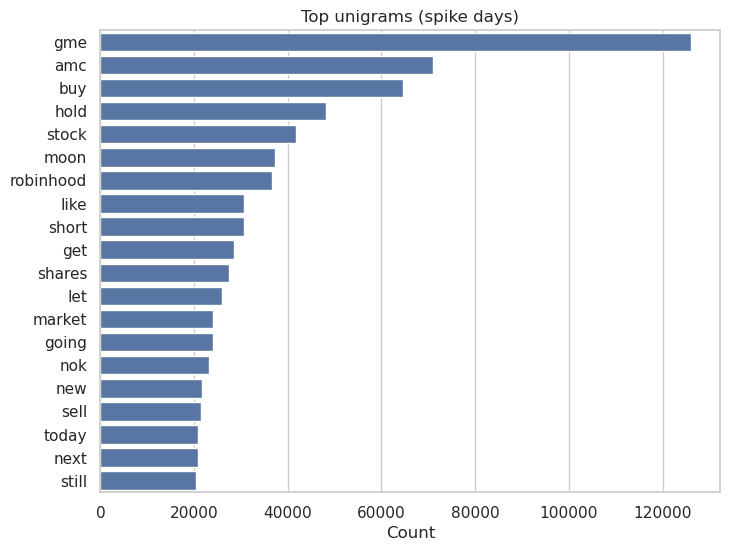

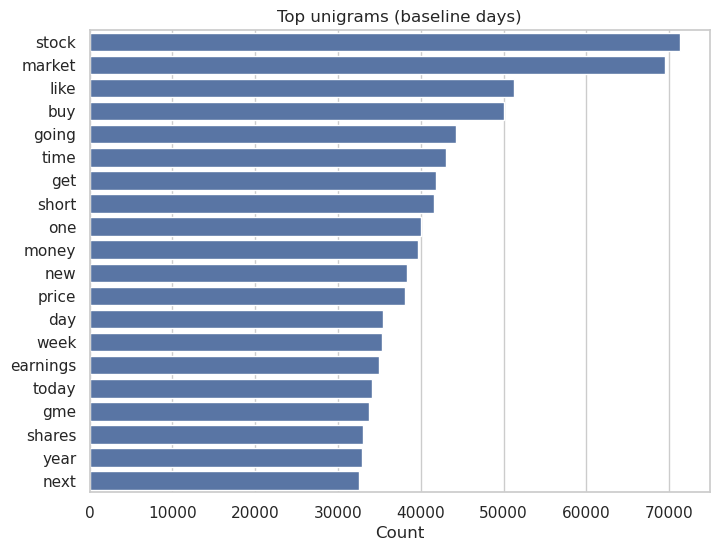

26/04/19 23:52:30 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/19 23:52:30 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/19 23:52:30 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/19 23:52:30 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/19 23:52:30 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/19 23:52:31 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
                                                                                

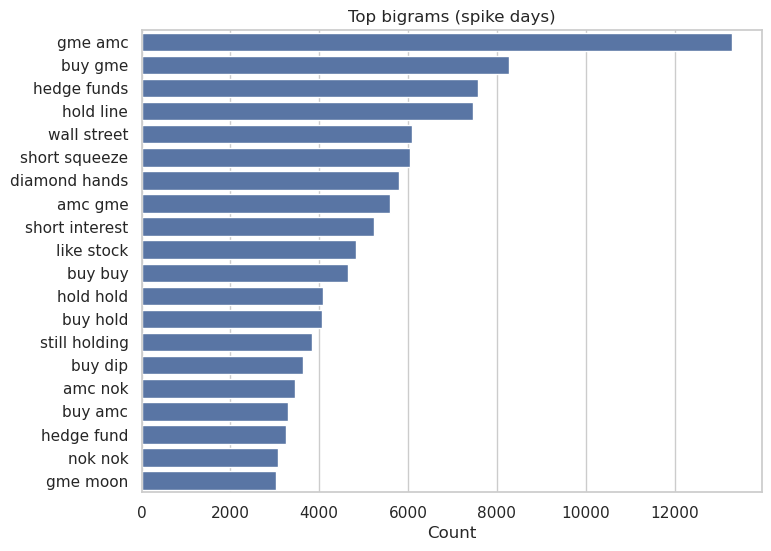

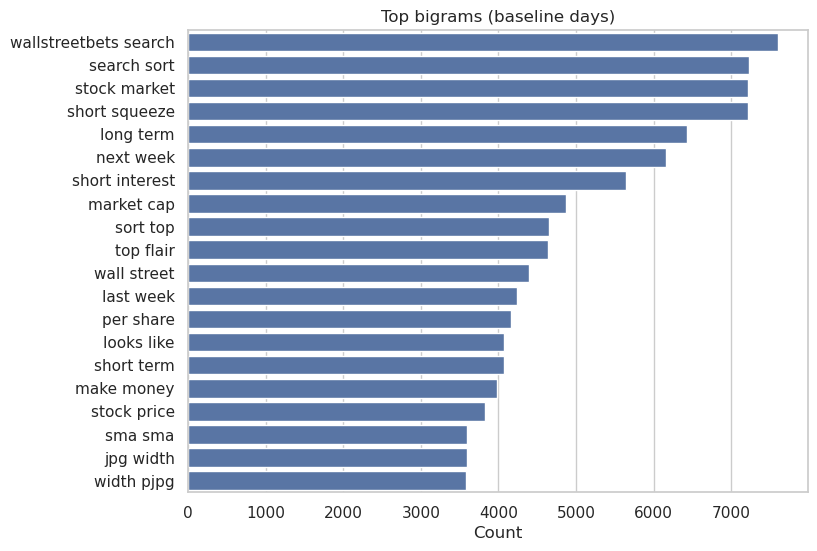

In [20]:
from pyspark.ml.feature import StopWordsRemover, NGram
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns

# Label spike days
spike_days_df = spark.createDataFrame([(d,) for d in spike_days], ["date"])

# Use submissions text for lighter processing
base_df = submissions.select("date", "text").dropna(subset=["text"])

# Tokenize: lowercase, remove non-letters, split
tokens = base_df.withColumn(
    "clean",
    F.regexp_replace(F.lower(F.col("text")), r"[^a-z\s]", " ")
).withColumn(
    "tokens",
    F.split(F.col("clean"), r"\s+")
)

# Remove stopwords and short tokens
remover = StopWordsRemover(inputCol="tokens", outputCol="filtered")
tokens = remover.transform(tokens).withColumn(
    "filtered",
    F.expr("filter(filtered, x -> length(x) >= 3)")
)

# Stronger cleanup: remove URL/boilerplate tokens
tokens = tokens.withColumn(
    "filtered",
    F.expr("""
        filter(filtered, x ->
            NOT (x rlike 'http|www|amp|png|webp|imgur|reddit|redd|com|preview') AND
            x NOT IN ('removed','auto','format')
        )
    """)
)

# Split into spike vs baseline
tokens_spike = tokens.join(spike_days_df, on="date", how="inner")
tokens_base = tokens.join(spike_days_df, on="date", how="left_anti")

# Top unigrams
top_unigrams_spike = (tokens_spike.select(F.explode("filtered").alias("token"))
                      .groupBy("token").count().orderBy(F.desc("count")).limit(20))
top_unigrams_base = (tokens_base.select(F.explode("filtered").alias("token"))
                     .groupBy("token").count().orderBy(F.desc("count")).limit(20))

uni_spike_pd = top_unigrams_spike.toPandas()
uni_base_pd = top_unigrams_base.toPandas()

plt.figure(figsize=(8, 6))
sns.barplot(data=uni_spike_pd, y="token", x="count")
plt.title("Top unigrams (spike days)")
plt.xlabel("Count")
plt.ylabel("")
plt.show()

plt.figure(figsize=(8, 6))
sns.barplot(data=uni_base_pd, y="token", x="count")
plt.title("Top unigrams (baseline days)")
plt.xlabel("Count")
plt.ylabel("")
plt.show()

# Bigrams
ngrammer = NGram(n=2, inputCol="filtered", outputCol="bigrams")
bigrams_spike = ngrammer.transform(tokens_spike)
bigrams_base = ngrammer.transform(tokens_base)

top_bigrams_spike = (bigrams_spike.select(F.explode("bigrams").alias("bigram"))
                     .groupBy("bigram").count().orderBy(F.desc("count")).limit(20))
top_bigrams_base = (bigrams_base.select(F.explode("bigrams").alias("bigram"))
                    .groupBy("bigram").count().orderBy(F.desc("count")).limit(20))

bi_spike_pd = top_bigrams_spike.toPandas()
bi_base_pd = top_bigrams_base.toPandas()

plt.figure(figsize=(8, 6))
sns.barplot(data=bi_spike_pd, y="bigram", x="count")
plt.title("Top bigrams (spike days)")
plt.xlabel("Count")
plt.ylabel("")
plt.show()

plt.figure(figsize=(8, 6))
sns.barplot(data=bi_base_pd, y="bigram", x="count")
plt.title("Top bigrams (baseline days)")
plt.xlabel("Count")
plt.ylabel("")
plt.show()

## Summary 

- Activity and unique-author spikes concentrate sharply in late Jan 2021, indicating coordinated attention bursts rather than steady growth.  
- Comments-per-submission surges during spikes suggest intensified collective focus and rapid feedback loops.  
- Engagement distributions are strongly heavy‑tailed (even after log1p), implying a small fraction of posts and users drive most interaction.  
- VADER sentiment varies over time and differs on spike days, consistent with emotionally charged periods rather than a flat baseline.  
- Spike-day unigrams/bigrams shift toward ticker- and action-oriented language (e.g., buy/hold/short squeeze), signaling coordination around shared targets.  
- Baseline language is broader and more routine, suggesting less synchronized discourse outside peak events.  
- The combination of volume spikes, participation surges, and vocabulary concentration supports the framing of emotion as a structuring force in collective attention.  
- These patterns motivate later modeling (TF‑IDF + clustering) to quantify how emotional alignment co-occurs with reduced linguistic diversity.